# Discontinuous AB Polycondensation

## 📖 Introduction

Polycondensation is a type of [step-growth polymerization] where two functional groups react to form a covalent bond while releasing a small molecule (*condensate*), such as water or methanol. Removing the condensate is typically required to shift the chemical equilibrium toward the polymer and achieve a high degree of polymerization.

The simplest case is AB polycondensation, in which each molecule (monomeric or polymeric) is bifunctional, containing one A and one B functional group. The production of [polylactic acid] (PLA) from lactic acid and of [Nylon 11] from 11-aminoundecanoic acid are representative examples of this class.

In this notebook, we model a discontinuous AB polycondensation, using the synthesis of PLA as our case study. To drive the reaction forward, our model accounts for the removal of the condensate through evaporation.

**Functional Group Approach**

If we neglect side reactions, the process is governed by the esterification between acid ($A$) and hydroxyl ($B$) groups:

$$ A + B \overset{k}{\underset{k'}{\rightleftarrows}} L + W $$

where $L$ is the linkage (ester bond), $W$ is water, $k$ is the forward (condensation) rate coefficient, and $k'$ is the backward (hydrolysis) rate coefficient. The two rate coefficients are related by the reaction equilibrium constant $K = k/k'$. 

Based on these definitions, the _net_ rate of esterification is given by:

\begin{equation}
r = k [A][B] - k' [L][W]
\end{equation}

or, equivalently, by:

\begin{equation}
r = k [A][B]\left( 1 - \frac{Q}{K} \right)
\end{equation}

where $Q = [L][W]/([A][B])$ is the [reaction quotient].

The rate of water removal is modeled as a mass-transfer process with the dominant resistance on the liquid side:

\begin{equation}
e_W = k_{\mathrm{L},W}([W] - [W^*])
\end{equation}

where $k_{\mathrm{L},W}$ denotes the liquid-side mass-transfer coefficient, and $[W^*]$ is the fictitious water concentration in equilibrium with the vapor phase. In principle, $[W^*]$ can be estimated using a vapor-liquid thermodynamic model, as explained in [Notebook 14]. Here, for the sake of simplicity, we will assume it to be a known process variable.

Assuming the process is conducted in a well-stirred tank reactor, the transient mole balances for the various species read:

\begin{align}
\frac{\mathrm{d}n_A}{\mathrm{d}t} &= -r V \\
\frac{\mathrm{d}n_B}{\mathrm{d}t} &= -r V \\
\frac{\mathrm{d}n_L}{\mathrm{d}t} &= +r V \\
\frac{\mathrm{d}n_W}{\mathrm{d}t} &= +r V - e_W V
\end{align}

where $n_i$ is the amount of species $i$, and $V$ is the volume of the liquid phase. 

The liquid-phase volume changes throughout the process and is approximated as:  

\begin{equation}
V \approx \left(\frac{n_A + n_B}{2}\right) v_M + n_L v_P + n_W v_W
\end{equation}

where $v_M$, $v_P$, and $v_W$ denote, respectively, the molar volume of the monomer, polymer segment, and water.

Although the 0th and 1st moments of the chain-length distribution are not explicitly tracked in this formulation, the number-average degree of polymerization can be easily computed from the state variables like so:

\begin{equation}
DP_{\mathrm{n}} = \frac{\text{# repeat units}}{\text{# chains}} = 1 + \frac{n_L}{(n_A + n_B)/2}
\end{equation}

This expression follows directly from the fact that each chain is *linear* and, thus, contains exactly two end groups.

**Population Balance Approach**

The functional group approach describes the overall (mean-field) progress of the system. In contrast, the population balance approach retains information about the full chain-length distribution. Specifically, it tracks reactions at the level of individual polymer chains:

$$ P_i + P_j \overset{2k}{\underset{k'}{\rightleftarrows}} P_{i+j} + W $$

where $P_i$ denotes a polymer chain of length $i \ge 1$, carrying one A and one B functional end group; $P_1$ denotes the monomer. The factor 2 accounts for the two *distinguishable* ways in which the A and B end groups of two chains can react.

With this formalism, the _net_ rate of esterification is given by: 

\begin{equation}
r =  k \left( \sum_{i=1}^{\infty} [P_i] \right)^2 - k'[W] \sum_{i=1}^{\infty} (i-1) [P_i]
\end{equation}

or, equivalently, by:

\begin{equation}
r =  k \lambda_0^2 - k'[W] \left(\lambda_1 - \lambda_0 \right)
\end{equation}

where $\lambda_m$ denotes the $m$-th moment of $[P_i]$.

In this case, the population balance equations governing the evolution of the amount of each polymeric species are:

\begin{equation}
\begin{aligned}
\frac{\mathrm{d}n_{P_i}}{\mathrm{d}t} = \Bigg(
& k \sum_{j=1}^{i-1} [P_{i-j}][P_j] - 2 k [P_i] \sum_{j=1}^{\infty} [P_j] \\
& + 2 k' [W] \sum_{j=i+1}^{\infty} [P_j] - k' [W] (i-1) [P_i]
\Bigg) V
\end{aligned}
\end{equation}

where the first two terms arise from the forward (condensation) reaction and the latter two from the backward (hydrolysis) reaction.

This completes the theoretical framework. We now implement the two approaches and discuss their predictions.

[step-growth polymerization]: https://en.wikipedia.org/wiki/Step-growth_polymerization
[polylactic acid]: https://en.wikipedia.org/wiki/Polylactic_acid
[Nylon 11]: https://en.wikipedia.org/wiki/Nylon_11
[reaction quotient]: https://en.wikipedia.org/wiki/Reaction_quotient
[Notebook 14]: ../14/devolatilization_static.ipynb

## 🔠 Functional Group Approach

We'll start with the functional group approach. Its straightforward nature makes it much easier to get right, serving as a baseline for verifying (or debugging) the more complex PBE model later.

In [1]:
from enum import IntEnum

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

To improve code readability, we define an enum mapping the variable names to the corresponding row index in the state vector and related arrays.

In [2]:
class Ix(IntEnum):
    A = 0  # acid group
    B = 1  # hydroxyl group
    L = 2  # linkage
    W = 3  # water

We will begin by implementing a helper function `arrhenius` to describe the temperature dependence of the rate coefficients.

In [3]:
def arrhenius(T: float, k0: float, Ea: float, T0: float) -> float:
    """Arrhenius equation.

    Parameters
    ----------
    T : float
        Temperature (°C).
    k0 : float
        Value of rate coefficient at `T0` (#/s).
    Ea : float
        Energy of activation (J/mol).
    T0 : float
        Reference temperature (°C).

    Returns
    -------
    float
        Value of rate coefficient at `T`.
    """
    R = 8.314  # J/(mol·K)
    return k0 * np.exp(-Ea / R * (1/(273.15 + T) - 1/(273.15 + T0)))

A dedicated auxiliary function is also provided to compute the liquid phase volume, as this calculation is required both during the integration and for post-processing.

In [4]:
def volume(nA: float | np.ndarray,
           nB: float | np.ndarray,
           nL: float | np.ndarray,
           nW: float | np.ndarray,
           params: dict
           ) -> float | np.ndarray:
    """Calculate the volume of the reaction mixture.

    Parameters
    ----------
    nA : float | np.ndarray
        Moles of acid groups (mol).
    nB : float | np.ndarray
        Moles of hydroxyl groups (mol).
    nL : float | np.ndarray
        Moles of linkages (mol).
    nW : float | np.ndarray
        Moles of water (mol).
    params : dict
        Dictionary of model parameters.

    Returns
    -------
    float | np.ndarray
        Volume of the reaction mixture (L).
    """
    v = params['v']
    return 0.5*(nA + nB)*v['M'] + nL*v['P'] + nW*v['W']

With these building blocks in place, we implement a function to compute the derivative of the state vector, which tracks the amounts of all species.

In [5]:
def model1_xdot(t: float,
                x: np.ndarray,
                T: float,
                params: dict,
                ) -> np.ndarray:
    """Calculate derivative of the state vector, dx/dt.

    x = [A, B, L, W]

    Parameters
    ----------
    t : float
        Time (s).
    x : np.ndarray
        State vector.
    T : float
        Temperature (°C).
    params : dict
        Model parameters.

    Returns
    -------
    np.ndarray
        Time derivative of the state vector.
    """

    # Unpack the moles vector (mol)
    n = x
    nA = n[Ix.A]
    nB = n[Ix.B]
    nL = n[Ix.L]
    nW = n[Ix.W]

    # Volume of the liquid phase (L)
    V = volume(nA, nB, nL, nW, params)

    # Molar concentrations (mol/L)
    A = nA / V
    B = nB / V
    L = nL / V
    W = nW / V

    # Net esterification rate (mol/(L·s))
    k = arrhenius(T, **params['k'])
    K = arrhenius(T, **params['K'])
    r = k*(A*B - L*W/K)

    # Evaporation rate of water (mol/(L·s))
    kLW = params['evaporation']['kLW']
    Wstar = params['evaporation']['W*']
    eW = kLW*max(0.0, W - Wstar)

    # Material balances (mol/s)
    xdot = np.empty_like(x)
    xdot[Ix.A] = - r * V
    xdot[Ix.B] = - r * V
    xdot[Ix.L] = + r * V
    xdot[Ix.W] = + (r - eW) * V

    return xdot

Finally, we perform the numerical integration using a suitable ODE solver. Since this system is non-stiff, we can use an explicit scheme like `RK45`.

In [6]:
def solve_model1(nM0: float,
                 T: float,
                 params: dict,
                 tend: float,
                 ) -> dict[str, np.ndarray]:
    """Solve the dynamic functional group model.

    Parameters
    ----------
    nM0 : float
        Initial amount of monomer (mol).
    T : float
        Temperature (°C).
    params : dict
        Model parameters.
    tend : float
        End simulation time (s).

    Returns
    -------
    dict[str, np.ndarray]
        times (`t`), moles (`n`).
    """

    # Initial conditions
    x0 = np.zeros(len(Ix))
    x0[Ix.A] = nM0
    x0[Ix.B] = nM0
    x0[Ix.L] = 0.0
    x0[Ix.W] = 0.0

    # Solve ODE set
    t_eval = np.linspace(0.0, tend, num=200)
    solution = solve_ivp(model1_xdot,
                         t_span=t_eval[(0, -1),],
                         y0=x0,
                         t_eval=t_eval,
                         args=(T, params),
                         method='RK45',
                         rtol=1e-5,
                         atol=1e-10)

    # Unpack the solution
    t = solution.t
    n = solution.y

    return {'t': t, 'n': n}

We adopt the kinetic parameters and temperature ranges reported by [Harshe et al. (2007)]. Feel free to experiment with these values, particularly the magnitudes of $k$ and $K$, to see how they influence the system behavior.

[Harshe et al. (2007)]: https://doi.org/10.1002/mren.200700019

In [7]:
params = {
    'k': {
        'k0': 1.2e-5, # L/(mol·s)
        'Ea': 31.1e3, # J/mol
        'T0': 150.0   # °C
    },
    'K': {
        'k0': 10.0, # -
        'Ea': 0e0,  # J/mol
        'T0': 150.0 # °C
    },
    'MM': {
        'M': 90.1, # g/mol
        'P': 72.1, # g/mol
        'W': 18.0  # g/mol
    },
    'v': {
        'M': 90.1/1.2e3,          # L/mol
        'P': (90.1 - 18.0)/1.2e3, # L/mol
        'W': 18.0/1e3,            # L/mol
    },
    'evaporation': {
        'kLW': 1e-3,  # 1/s
        'W*': 1e-3    # mol/L
    }
}

Let's run a single simulation and check if the results make sense. 

In [8]:
sol = solve_model1(nM0=10, T=180, params=params, tend=20*3600)

sol['n'][:, -1] # final moles vector

array([3.98636554e-01, 3.98636554e-01, 9.60136345e+00, 6.19132062e-03])

The results look plausible, but a visual representation will be more informative. The following function runs the model across a range of temperatures and generates time profiles for the key system properties.

In [9]:
def plot_model1_solution(
    nM0: float,
    temperatures: list[float],
    params: dict,
    tend: float,
    title: str
) -> None:
    """Plot the model1 solution for different temperatures.

    Parameters
    ----------
    nM0 : float
        Initial amount of monomer (mol).
    temperatures : list[float]
        Temperatures (°C).
    params : dict
        Model parameters.
    tend : float
        End simulation time (s).
    title : str
        Plot title.
    """

    fig, ax = plt.subplots(5, 1, sharex=True, figsize=(6, 5*2))
    fig.suptitle(title)
    fig.tight_layout()
    fig.align_ylabels()

    for T in temperatures:

        sol = solve_model1(nM0, T, params, tend)
        
        t_hour = sol['t'] / 3600
        nA = sol['n'][Ix.A, :]
        nB = sol['n'][Ix.B, :]
        nL = sol['n'][Ix.L, :]
        nW = sol['n'][Ix.W, :]
        
        # Volume of the reaction mixture (L)
        V = volume(nA, nB, nL, nW, params)

        # End-group conversion
        X = nL/(nA + nL)
        ax[0].plot(t_hour, X, label=f"{T:.0f} °C")
        ax[0].set_ylabel("Conversion")
        ax[0].set_ylim(0.0, 1.0)
        ax[0].grid(True)
        ax[0].legend(loc="lower right")

        # Degree of polymerization
        DPn = 1 + 2*nL/(nA + nB)
        ax[1].plot(t_hour, DPn)
        ax[1].set_ylabel(r"$DP_{\mathrm{n}}$")
        ax[1].grid(True)

        # Reaction quotient
        Q = (nL * nW) / (nA * nB)
        K = arrhenius(T, **params['K'])
        ax[2].plot(t_hour, Q/K)
        ax[2].set_ylabel(r"$Q/K$")
        ax[2].grid(True)

        # Water concentration
        W = nW / V
        ax[3].plot(t_hour, W)
        ax[3].set_ylabel("[W] (mol/L)")
        ax[3].grid(True)

        # Volume
        ax[4].plot(t_hour, V)
        ax[4].set_ylabel("Volume (L)")
        ax[4].grid(True)

        ax[-1].set_xlabel("Time (hour)")

Let us begin by simulating the behavior in a closed vessel, i.e., without the removal of water. This allows us to observe the system as it approaches chemical equilibrium.

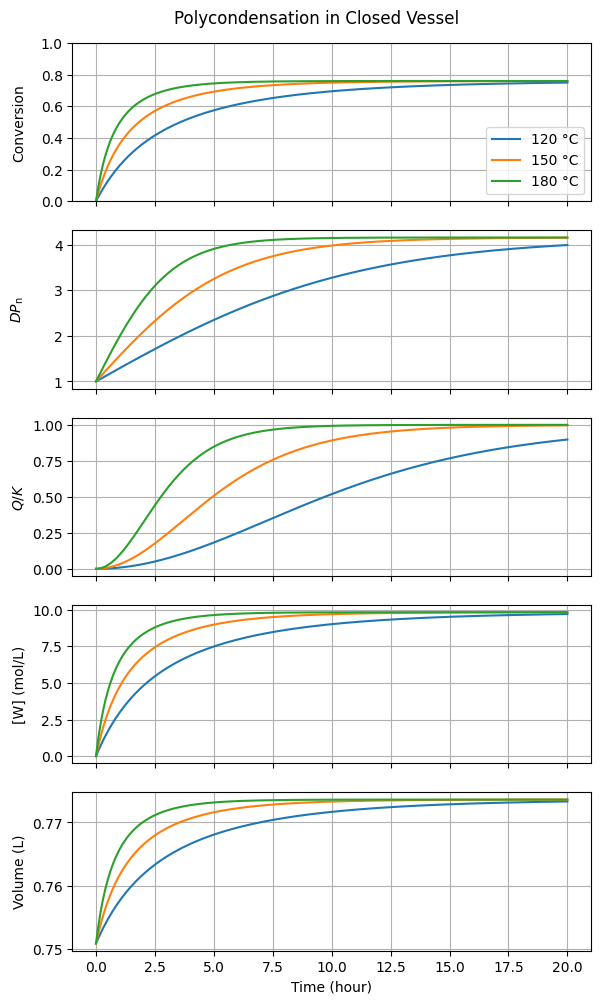

In [10]:
params['evaporation']['kLW'] = 0.0 # closed vessel

plot_model1_solution(
    nM0=10,
    temperatures=[120, 150, 180],
    params=params,
    tend=20*3600,
    title="Polycondensation in Closed Vessel"
)

Increasing the temperature accelerates the initial reaction rate but does not affect the final equilibrium conversion or the degree of polymerization. This occurs because these quantities are governed by the equilibrium constant $K$, which we have assumed to be temperature-independent. This behavior is typical of polyesterifications, as they are nearly athermal.

```{admonition} Van 't Hoff equation
:class: dropdown tip
The Van 't Hoff equation relates the temperature dependence of the equilibrium constant to the heat of reaction: $\mathrm{d} \ln K /\mathrm{d} T =  \Delta_{\mathrm{r}} H/ (R T^2)$. Consequently, (almost) athermal processes ($\Delta_{\mathrm{r}} H \approx 0$) exhibit (almost) temperature-independent equilibrium constants.
``` 

Now, we repeat the simulation for an open system, assuming a fairly high mass-transfer coefficient ($k_{\mathrm{L},W}$) and a low fictitious water concentration ($[W^*]$). Feel free to play with these values.

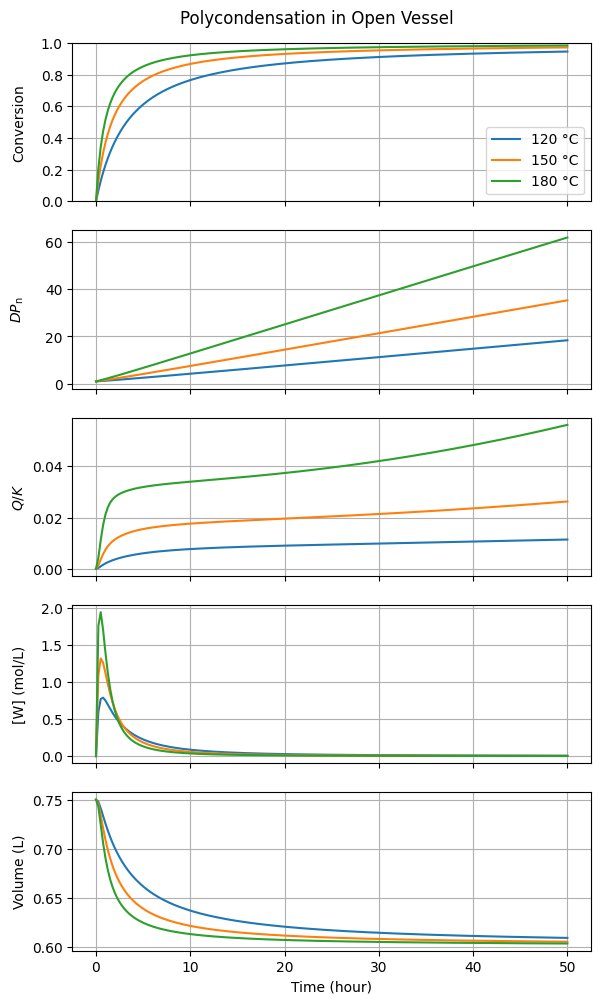

In [11]:
params['evaporation']['kLW'] = 1e-3 # 1/s
params['evaporation']['W*'] = 1e-3  # mol/L

plot_model1_solution(
    nM0=10,
    temperatures=[120, 150, 180],
    params=params,
    tend=50*3600,
    title="Polycondensation in Open Vessel"
)

Under these particular water removal conditions, the contribution of the reverse reaction, indicated by the ratio $Q/K$, remains small. Consequently, the conversion of end groups and the degree of polymerization increase with almost no thermodynamic resistance. 

Note that $[W] \gg [W^*]$ during the initial stages because the rate of esterification significantly exceeds the rate of evaporation. However, the impact on the conversion trajectory is minimal; you can convince yourself of this by increasing $k_{\mathrm{L},W}$ by an order of magnitude and observing the nearly imperceptible change in the results.

The *linear* increase of $DP_{\mathrm{n}}$ over time is also worth noticing. This might seem counter-intuitive and could perhaps even be mistaken for a "bug." However, this is actually the theoretically expected behavior for a linear, stoichiometric polycondensation with second-order kinetics (see [Questions](#questions)).

## 📉 Population Balance Approach

In this implementation, we reuse three helper functions from [Notebook 1] to compute the right-hand side of the population balance equations and the distribution moments.

[Notebook 1]: ../01/population_balances.ipynb

In [12]:
def combination(P: np.ndarray, k: float) -> np.ndarray:
    """P(i) + P(j) -> P(i+j) , k

    d[P(i)]/dt = 0.5*k* sum j=1:i-1 [P(i-j)]*[P(j)] - k*[P(i)]*sum([P(j)])
    """
    Pplus = 0.5 * np.convolve(P, P, mode='full')[:P.size]
    Pminus = P*P.sum()
    return k*(Pplus - Pminus)

In [13]:
def scission(P: np.ndarray, k: float) -> np.ndarray:
    """P(i) -> P(i-j) + P(j) , k
    
    d[P(i)]/dt = 2*k* sum j=i+1:∞ [P(j)] - k*(i-1)*[P(i)]
    """
    # Source term
    Pplus = np.zeros_like(P)
    Pplus[1:-1] = 2* np.cumsum(P[2:][::-1])[::-1]
    # Sink term
    s = np.arange(0, P.size)
    Pminus = (s - 1)*P
    Pminus[0] = 0.0
    return k*(Pplus - Pminus)

In [14]:
def moment(P: np.ndarray, m: int) -> float | np.ndarray:
    """m-th moment of `P`.

    Parameters
    ----------
    P : np.ndarray
        Distribution.
    m : int
        Order of moment.

    Returns
    -------
    float | np.ndarray
        Moment of distribution `P`.
    """
    s = np.arange(0, P.shape[0])
    return np.dot(s**m, P)

Using these building blocks, we define a function to calculate the rate of change of the state vector, capturing the temporal evolution of all polymer species and water.

In [15]:
def model2_xdot(t: float,
                x: np.ndarray,
                T: float,
                params: dict,
                ) -> np.ndarray:
    """Calculate derivative of the state vector, dx/dt.

    x = [P_0..P_N, W]

    Parameters
    ----------
    t : float
        Time (s).
    x : np.ndarray
        State vector.
    T : float
        Temperature (°C).
    params : dict
        Model parameters.

    Returns
    -------
    np.ndarray
        Time derivative of the state vector.
    """

    # Unpack the moles vector (mol)
    n = x
    nP = n[:-1]
    nW = n[-1]

    # Volume of the liquid phase (L)
    nP0 = moment(nP, 0)
    nP1 = moment(nP, 1)
    V = volume(nP0, nP0, (nP1 - nP0), nW, params)

    # Molar concentrations (mol/L)
    P = nP / V
    W = nW / V

    # Moments of P
    p0 = moment(P, 0)
    p1 = moment(P, 1)

    # Net esterification rate (mol/(L·s))
    k = arrhenius(T, **params['k'])
    K = arrhenius(T, **params['K'])
    r = k*(p0**2 - (p1 - p0)*W/K)

    # Evaporation rate of water (mol/(L·s))
    kLW = params['evaporation']['kLW']
    Wstar = params['evaporation']['W*']
    eW = kLW*max(0.0, W - Wstar)

    # Net rate of polymer(i) formation (mol/(L·s))
    rP = combination(P, 2*k) + scission(P, (k/K)*W)

    # Material balances (mol/s)
    xdot = np.empty_like(x)
    xdot[:-1] = + rP * V
    xdot[-1] = + (r - eW) * V

    return xdot

Consistent with our previous approach, we perform the numerical integration using an appropriate ODE solver.

In [ ]:
def solve_model2(nM0: float,
                 T: float,
                 params: dict,
                 tend: float,
                 N: int = 1_000
                 ) -> dict[str, np.ndarray]:
    """Solve the dynamic PBE model.

    Parameters
    ----------
    nM0 : float
        Initial amount of monomer (mol).
    T : float
        Temperature (°C).
    params : dict
        Model parameters.
    tend : float
        End simulation time (s).
    N : int
        Maximum polymer chain length to consider.

    Returns
    -------
    dict[str, np.ndarray]
        times (`t`), moles (`n`).
    """

    # Chain lengths (include length 0, to make indexing easier)
    s = np.arange(0, N+1)

    # Initial conditions
    x0 = np.zeros(s.size + 1)
    x0[1]  = nM0  # monomer
    x0[-1] = 0.0  # water

    # Solve ODE set
    t_eval = np.linspace(0.0, tend, num=200)
    solution = solve_ivp(model2_xdot,
                         t_span=t_eval[(0, -1),],
                         y0=x0,
                         t_eval=t_eval,
                         args=(T, params),
                         method='RK45',
                         rtol=1e-5,
                         atol=1e-10)

    # Unpack the solution
    t = solution.t
    n = solution.y

    return {'t': t, 'n': n}

Let's run a single simulation and check if the results make sense. 

In [17]:
sol = solve_model2(nM0=10, T=180, params=params, tend=20*3600)

sol['n'][:, -1] # final moles vector

array([0.00000000e+00, 1.58911940e-02, 1.52575821e-02, ...,
       3.70353113e-20, 3.55563414e-20, 6.19246279e-03], shape=(1002,))

This works, but looking at the raw numbers doesn’t make it easy to see what’s happening.
The next function runs the model for a range of temperatures and plots the time evolution of the main system properties, making the results much easier to understand.

In [18]:
def plot_model2_solution(
    nM0: float,
    temperatures: list[float],
    params: dict,
    tend: float,
    title: str
) -> None:
    """Plot the model2 solution for different temperatures.

    Parameters
    ----------
    nM0 : float
        Initial amount of monomer (mol).
    temperatures : list[float]
        Temperatures (°C).
    params : dict
        Model parameters.
    tend : float
        End simulation time (s).
    title : str
        Plot title.
    """

    fig = plt.figure(figsize=(6, 7*2))

    # Customization to add extra space above GPC plot
    gs = fig.add_gridspec(
        nrows=8, ncols=1,
        height_ratios=[1, 1, 1, 1, 1, 1, 0.3, 1],
        hspace=0.25
    )
    ax = [fig.add_subplot(gs[i, 0]) for i in range(6)]
    ax.append(fig.add_subplot(gs[7, 0]))
    plt.setp([a.get_xticklabels() for a in ax[:5]], visible=False)

    fig.suptitle(title)
    fig.subplots_adjust(top=0.95)
    fig.align_ylabels()

    for T in temperatures:

        sol = solve_model2(nM0, T, params, tend)
        
        t_hour = sol['t'] / 3600
        nP = sol['n'][:-1, :]
        nW = sol['n'][-1, :]

        # Moments of nP
        nP0 = moment(nP, 0)
        nP1 = moment(nP, 1)
        nP2 = moment(nP, 2)

        # Volume of the reaction mixture (L)
        V = volume(nP0, nP0, (nP1 - nP0), nW, params)

        # End-group conversion
        X = 1.0 - nP0 / nP0[0]
        ax[0].plot(t_hour, X, label=f"{T:.0f} °C")
        ax[0].set_ylabel("Conversion")
        ax[0].set_ylim(0.0, 1.0)
        ax[0].grid(True)
        ax[0].legend(loc="lower right")

        # Degree of polymerization
        DPn = nP1 / nP0
        ax[1].plot(t_hour, DPn)
        ax[1].set_ylabel(r"$DP_{\mathrm{n}}$")
        ax[1].grid(True)

        # PDI
        PDI = nP2 * nP0 / nP1**2
        ax[2].plot(t_hour, PDI)
        ax[2].set_ylabel("PDI")
        ax[2].grid(True)

        # Reaction quotient
        p0 = nP0 / V
        p1 = nP1 / V
        W = nW / V
        Q = (p1 - p0) * W / p0**2
        K = arrhenius(T, **params['K'])
        ax[3].plot(t_hour, Q/K)
        ax[3].set_ylabel(r"$Q/K$")
        ax[3].grid(True)

        # Water concentration
        ax[4].plot(t_hour, W)
        ax[4].set_ylabel("[W] (mol/L)")
        ax[4].grid(True)

        # Volume
        ax[5].plot(t_hour, V)
        ax[5].set_ylabel("Volume (L)")
        ax[5].grid(True)
        ax[5].set_xlabel("Time (hour)")

        # GPC-like molecular weight distribution
        s = np.arange(0, nP.shape[0])
        GPC = nP[:, -1] * s**2
        GPC /= GPC.max()
        ax[6].plot(s*params['MM']['P'], GPC)
        ax[6].set_xlabel("Molar mass (g/mol)")
        ax[6].set_ylabel(r"$w(\log(M))$")
        ax[6].set_xscale('log')
        ax[6].grid(True)


To compare this with the functional group approach, we rerun the open-vessel simulation under identical operating conditions.

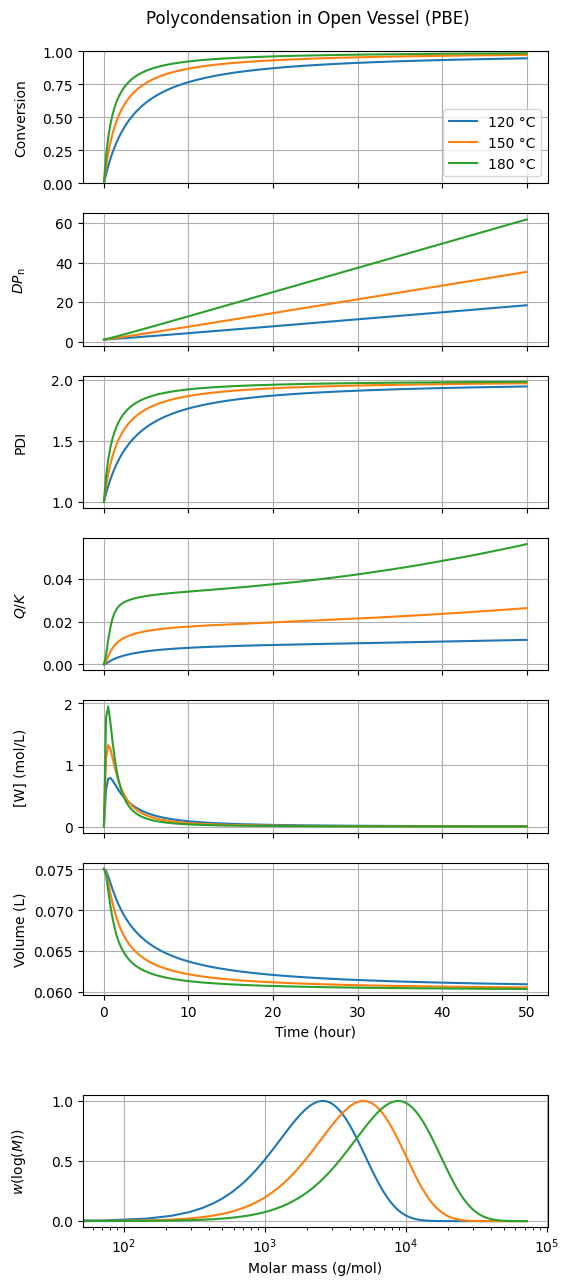

In [19]:
plot_model2_solution(
    nM0=1.0,
    temperatures=[120, 150, 180],
    params=params,
    tend=50*3600,
    title="Polycondensation in Open Vessel (PBE)"
)

The results for conversion, $DP_{\mathrm{n}}$, and other metrics obtained with both approaches are in perfect agreement. The primary advantage of the PBE method is its inherent ability to provide information about the chain-length distribution, such as the polydispersity index (PDI) or the full distribution shape.

## 🔎 Questions

1. Show that, for an irreversible AB polycondensation with second-order kinetics, the number-average degree of polymerization ($DP_{\mathrm{n}}$) increases linearly with time.
2. Modify the logic for setting the initial conditions in `solve_model2` so that you can simulate a PLA depolymerization. Then, run a simulation at 180 °C with 50 wt% water.
3. The functional group equations are actually quite general. Show how they can be used to model an arbitrary AA + BB system.
4. Derive the population balance equations for an arbitrary AA + BB system. 
    * Hint: Start by considering only the forward (condensation) reaction. The backward (hydrolysis) reaction is deceptively more complex.